In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# path setup
script_dir = os.getcwd()
csv_folder = os.path.join(script_dir, "extracted_csv")

# choose files to plot
selected_files = [
    "Test_PD_CompleteS_2.2.csv"
]

print("Selected files:")
for f in selected_files:
    print(f)

Selected files:
Test_PD_CompleteS_2.2.csv


In [10]:
data = {}

for file in selected_files:
    
    path = os.path.join(csv_folder, file)
    
    df = pd.read_csv(path)
    
    data[file] = df
    
    print(file, "loaded")
    display(df.head())

Test_PD_CompleteS_2.2.csv loaded


,ros_time,ego_position,ego_velocity,lead_position,lead_velocity,separation,throttle_command,warning
0,1.773398e+09,0.0,0.0,NaN,NaN,NaN,0.344265,0
1,1.773398e+09,0.0,0.0,NaN,NaN,NaN,0.344265,0
2,1.773398e+09,0.0,0.0,NaN,NaN,NaN,0.688530,0
3,1.773398e+09,0.0,0.0,NaN,NaN,NaN,0.688530,0
4,1.773398e+09,0.0,0.0,NaN,NaN,NaN,0.688530,0


In [11]:
df["time"] = df["ros_time"] - df["ros_time"].iloc[0]

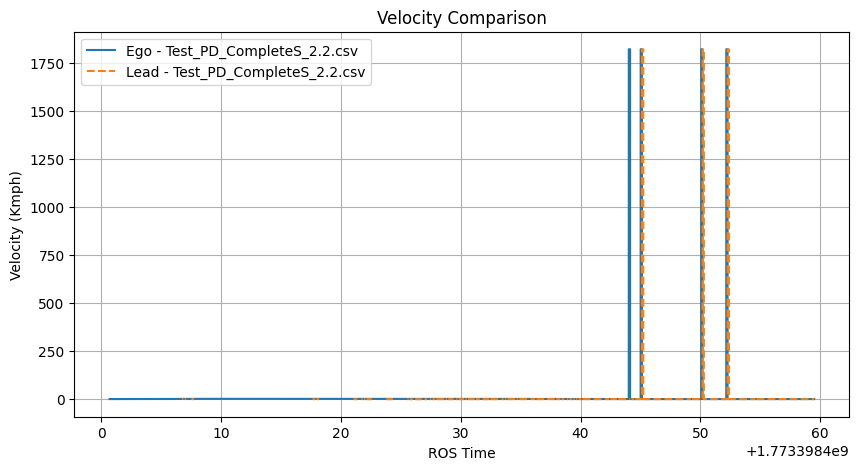

In [12]:
plt.figure(figsize=(10,5))

for file, df in data.items():
    
    plt.plot(df["ros_time"], df["ego_velocity"], label=f"Ego - {file}")
    
    if "lead_velocity" in df.columns:
        plt.plot(df["ros_time"], df["lead_velocity"], linestyle="--", label=f"Lead - {file}")

plt.xlabel("ROS Time")
plt.ylabel("Velocity (Kmph)")
plt.title("Velocity Comparison")
plt.legend()
plt.grid()
plt.show()

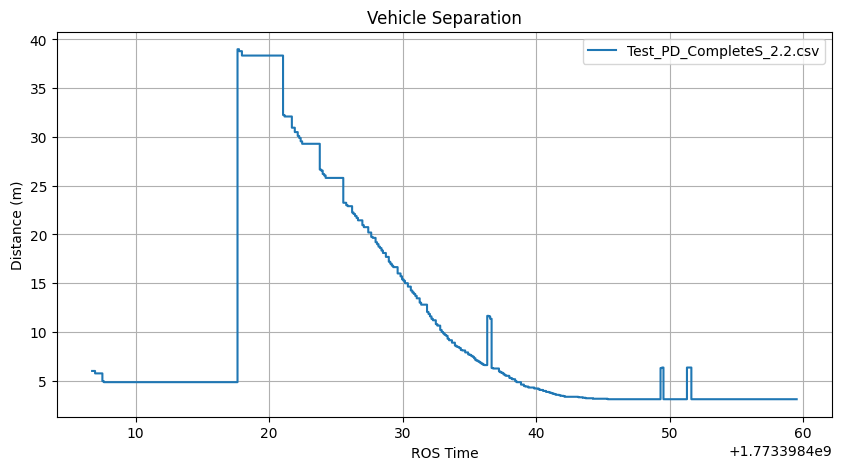

In [13]:
plt.figure(figsize=(10,5))

for file, df in data.items():

    if "separation" in df.columns:
        plt.plot(df["ros_time"], df["separation"], label=file)

plt.xlabel("ROS Time")
plt.ylabel("Distance (m)")
plt.title("Vehicle Separation")
plt.legend()
plt.grid()
plt.show()

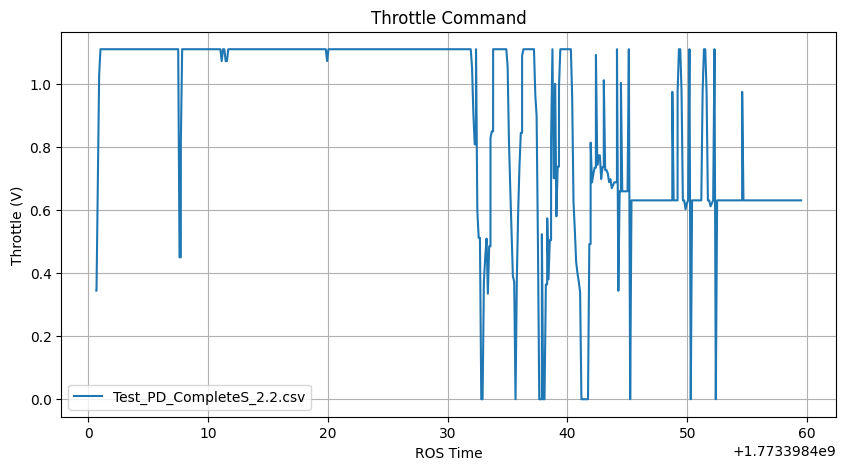

In [14]:
plt.figure(figsize=(10,5))

for file, df in data.items():
    
    plt.plot(df["ros_time"], df["throttle_command"], label=file)

plt.xlabel("ROS Time")
plt.ylabel("Throttle (V)")
plt.title("Throttle Command")
plt.legend()
plt.grid()
plt.show()

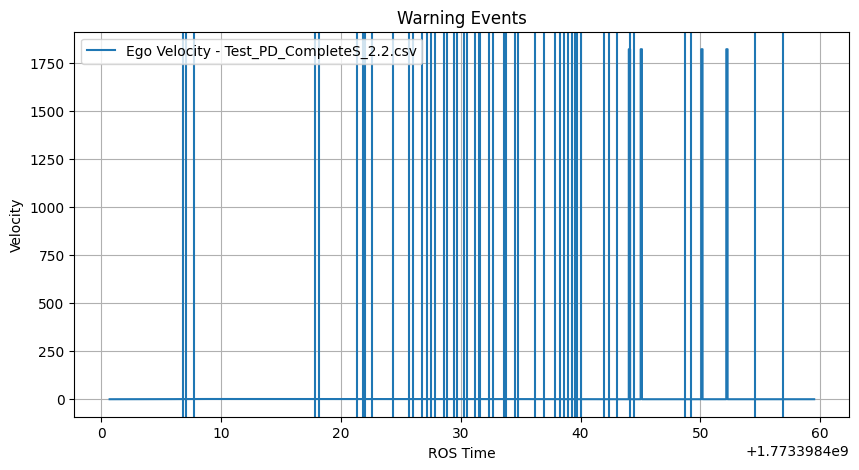

In [15]:
plt.figure(figsize=(10,5))

for file, df in data.items():

    plt.plot(df["ros_time"], df["ego_velocity"], label=f"Ego Velocity - {file}")
    
    warn_times = df[df["warning"] == 1]["ros_time"]
    
    for w in warn_times:
        plt.axvline(x=w)

plt.xlabel("ROS Time")
plt.ylabel("Velocity")
plt.title("Warning Events")
plt.legend()
plt.grid()
plt.show()